# DWTS 数据预处理

## 问题背景
《与星共舞》(Dancing with the Stars) 是一档舞蹈真人秀节目，本问题需要分析34季数据，估算观众投票、比较投票方式、分析影响因素并设计新系统。

## 建模方法规划
- **问题一**（估算粉丝投票）：贝叶斯推断、约束优化
- **问题二**（投票方式比较）：反事实分析、因果推断
- **问题三**（因素影响分析）：混合效应模型、中介分析、ANOVA
- **问题四**（新系统设计）：多目标优化、博弈论

## 预处理目标
1. 加载并理解所有数据
2. 处理缺失值和特殊值（0分、N/A）
3. 构建每周评委得分汇总
4. 合并额外数据（pageviews、pro_dancer_stats等）
5. 特征工程：构建建模所需变量

## 第一步：数据加载与初探

In [1]:
# 标准导入
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置显示选项
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# 智能读取CSV函数
def smart_read_csv(filepath, **kwargs):
    """智能读取CSV，自动尝试不同编码"""
    encodings = ['utf-8', 'gbk', 'gb2312', 'latin-1', 'cp1252']
    for encoding in encodings:
        try:
            df = pd.read_csv(filepath, encoding=encoding, **kwargs)
            print(f"✅ 成功读取 {filepath.split('/')[-1]} (编码: {encoding})")
            return df
        except UnicodeDecodeError:
            continue
    print(f"❌ 所有编码尝试失败: {filepath}")
    return None

In [3]:
# 加载主数据
df_main = smart_read_csv('../2026_MCM_Problem_C_Data.csv')

# 加载额外数据
df_pageviews = smart_read_csv('../额外补充数据集/external_outputs/pageviews_s21_s34.csv')
df_pro_dancer = smart_read_csv('../额外补充数据集/external_outputs/pro_dancer_stats.csv')
df_season_meta = smart_read_csv('../额外补充数据集/external_outputs/season_metadata.csv')

✅ 成功读取 2026_MCM_Problem_C_Data.csv (编码: utf-8)
✅ 成功读取 pageviews_s21_s34.csv (编码: utf-8)
✅ 成功读取 pro_dancer_stats.csv (编码: utf-8)
✅ 成功读取 season_metadata.csv (编码: utf-8)


In [4]:
# 查看主数据基本信息
print("="*60)
print("📊 主数据集基本信息")
print("="*60)
print(f"\n形状: {df_main.shape[0]} 行 × {df_main.shape[1]} 列")
print(f"\n列名:")
for i, col in enumerate(df_main.columns):
    if i < 9:  # 前9列基本信息
        print(f"  {i+1}. {col}")
    elif i == 9:
        print(f"  10-{len(df_main.columns)}. week1_judge1_score ... week11_judge4_score (评委打分)")
        break

📊 主数据集基本信息

形状: 421 行 × 53 列

列名:
  1. celebrity_name
  2. ballroom_partner
  3. celebrity_industry
  4. celebrity_homestate
  5. celebrity_homecountry/region
  6. celebrity_age_during_season
  7. season
  8. results
  9. placement
  10-53. week1_judge1_score ... week11_judge4_score (评委打分)


In [5]:
# 查看数据类型和非空统计
print("\n主数据Info:")
df_main.info()


主数据Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421 entries, 0 to 420
Data columns (total 53 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   celebrity_name                421 non-null    object 
 1   ballroom_partner              421 non-null    object 
 2   celebrity_industry            421 non-null    object 
 3   celebrity_homestate           365 non-null    object 
 4   celebrity_homecountry/region  421 non-null    object 
 5   celebrity_age_during_season   421 non-null    int64  
 6   season                        421 non-null    int64  
 7   results                       421 non-null    object 
 8   placement                     421 non-null    int64  
 9   week1_judge1_score            421 non-null    float64
 10  week1_judge2_score            421 non-null    float64
 11  week1_judge3_score            407 non-null    float64
 12  week1_judge4_score            81 non-null     float64


In [6]:
# 查看前几行
print("\n主数据前5行（基本信息列）:")
df_main.iloc[:5, :9]


主数据前5行（基本信息列）:


,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age_during_season,season,results,placement
0,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,1,2nd Place,2
1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,1
2,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,1,Eliminated Week 3,5
3,Rachel Hunter,Jonathan Roberts,Model,NaN,New Zealand,35,1,Eliminated Week 4,4
4,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,1,3rd Place,3


In [7]:
# 查看打分列示例
print("\n评委打分示例（第1周）:")
score_cols = [c for c in df_main.columns if 'week1_' in c]
df_main[['celebrity_name', 'season'] + score_cols].head(10)


评委打分示例（第1周）:


,celebrity_name,season,week1_judge1_score,week1_judge2_score,week1_judge3_score,week1_judge4_score
0,John O'Hurley,1,7.00,7.00,6.00,NaN
1,Kelly Monaco,1,5.00,4.00,4.00,NaN
2,Evander Holyfield,1,5.00,7.00,6.00,NaN
3,Rachel Hunter,1,7.00,6.00,7.00,NaN
4,Joey McIntyre,1,7.00,7.00,6.00,NaN
5,Trista Sutter,1,6.00,6.00,6.00,NaN
6,Tatum O'Neal,2,7.00,8.00,8.00,NaN
7,Tia Carrere,2,6.00,7.00,7.00,NaN
8,George Hamilton,2,7.00,5.00,6.00,NaN
9,Lisa Rinna,2,5.00,7.00,7.00,NaN


In [8]:
# 查看额外数据
print("\n📊 额外数据集概览")
print("="*60)
print(f"\nPageviews数据 (S21-S34): {df_pageviews.shape}")
print(df_pageviews.head(3))

print(f"\nPro Dancer统计: {df_pro_dancer.shape}")
print(df_pro_dancer.head(3))

print(f"\nSeason元数据: {df_season_meta.shape}")
print(df_season_meta.head(3))


📊 额外数据集概览

Pageviews数据 (S21-S34): (183, 7)
    celebrity_name  season       wiki_title  total_pageviews  \
0       Gary Busey      21       Gary Busey           949875   
1   Alexa PenaVega      21   Alexa PenaVega           156918   
2  Carlos PenaVega      21  Carlos PenaVega            66029   

   avg_daily_pageviews  max_daily_pageviews  days_with_data  
0             13378.50               200821              71  
1              2210.10                22579              71  
2               930.00                10452              71  

Pro Dancer统计: (60, 10)
              pro_dancer  seasons_participated  total_partners  wins  \
0            Derek Hough                    17              17     6   
1            Mark Ballas                    21              20     3   
2  Valentin Chmerkovskiy                    19              19     3   

   top3_finishes  avg_placement  avg_score  first_season  last_season  \
0              9           2.94       8.88             5         

## 第二步：数据清洗与缺失值处理

根据题目说明：
- **N/A值**：1）该周无第4位评委；2）该季未播出的周次
- **0分**：选手已被淘汰后的周次记录为0

In [9]:
# 数据质量报告函数
def data_quality_report(df, name="DataFrame"):
    """生成数据质量报告"""
    print(f"📊 数据质量报告: {name}")
    print(f"📏 形状: {df.shape[0]} 行 × {df.shape[1]} 列")
    
    # 缺失值统计
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_df = pd.DataFrame({'缺失数': missing, '缺失率%': missing_pct})
    missing_df = missing_df[missing_df['缺失数'] > 0].sort_values('缺失率%', ascending=False)
    
    if len(missing_df) > 0:
        print(f"\n⚠️ 缺失值统计 ({len(missing_df)} 列有缺失):")
        print(missing_df.head(20))  # 只显示前20个
    else:
        print("\n✅ 无缺失值")
    
    # 重复值
    dup_count = df.duplicated().sum()
    print(f"\n🔄 重复行数: {dup_count} ({dup_count/len(df)*100:.2f}%)")
    
    return missing_df

missing_report = data_quality_report(df_main, "DWTS主数据")

📊 数据质量报告: DWTS主数据
📏 形状: 421 行 × 53 列

⚠️ 缺失值统计 (34 列有缺失):
                     缺失数  缺失率%
week11_judge4_score  395 93.82
week1_judge4_score   340 80.76
week2_judge4_score   330 78.38
week10_judge4_score  328 77.91
week8_judge4_score   313 74.35
week11_judge3_score  302 71.73
week11_judge2_score  302 71.73
week11_judge1_score  302 71.73
week5_judge4_score   302 71.73
week3_judge4_score   293 69.60
week4_judge4_score   291 69.12
week9_judge4_score   288 68.41
week7_judge4_score   277 65.80
week6_judge4_score   274 65.08
celebrity_homestate   56 13.30
week10_judge3_score   52 12.35
week10_judge2_score   52 12.35
week10_judge1_score   52 12.35
week9_judge3_score    26  6.18
week9_judge1_score    26  6.18

🔄 重复行数: 0 (0.00%)


In [10]:
# 分析N/A值的含义
# 识别所有评分列
score_cols_all = [c for c in df_main.columns if 'judge' in c and 'score' in c]
print(f"评分列数量: {len(score_cols_all)}")

# 统计N/A和0的分布
na_counts = {}
zero_counts = {}
for col in score_cols_all:
    na_counts[col] = df_main[col].isna().sum()
    # 0分需要先转为数值判断
    numeric_col = pd.to_numeric(df_main[col], errors='coerce')
    zero_counts[col] = (numeric_col == 0).sum()

print(f"\nN/A值总数: {sum(na_counts.values())}")
print(f"0分总数: {sum(zero_counts.values())}")

评分列数量: 44

N/A值总数: 4741
0分总数: 4671


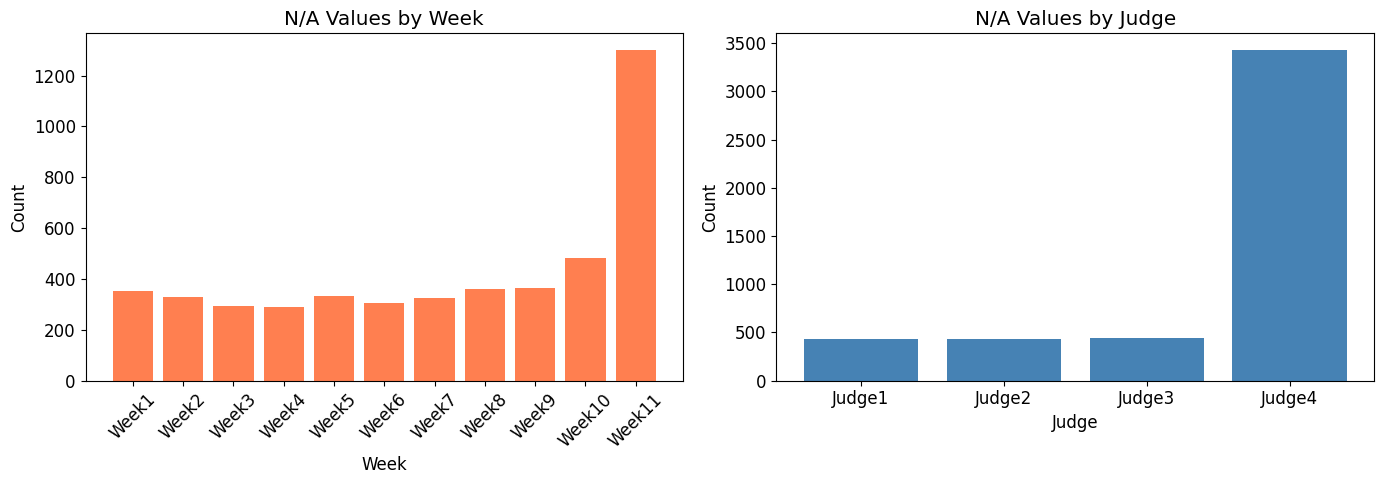


分析结论：
- Judge4的N/A最多：大多数季只有3个评委
- 后期周次N/A更多：早期淘汰选手/短季节


In [11]:
# 可视化N/A分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 按周汇总N/A
na_by_week = {}
for week in range(1, 12):
    week_cols = [c for c in score_cols_all if f'week{week}_' in c]
    na_by_week[f'Week{week}'] = sum(df_main[col].isna().sum() for col in week_cols)

axes[0].bar(na_by_week.keys(), na_by_week.values(), color='coral')
axes[0].set_title('N/A Values by Week')
axes[0].set_xlabel('Week')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# 按Judge汇总N/A
na_by_judge = {}
for judge in range(1, 5):
    judge_cols = [c for c in score_cols_all if f'judge{judge}_' in c]
    na_by_judge[f'Judge{judge}'] = sum(df_main[col].isna().sum() for col in judge_cols)

axes[1].bar(na_by_judge.keys(), na_by_judge.values(), color='steelblue')
axes[1].set_title('N/A Values by Judge')
axes[1].set_xlabel('Judge')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('fig1_na_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n分析结论：")
print("- Judge4的N/A最多：大多数季只有3个评委")
print("- 后期周次N/A更多：早期淘汰选手/短季节")

In [12]:
# 检查celebrity_homestate的缺失值
print("\ncelebrity_homestate缺失分析:")
missing_state = df_main[df_main['celebrity_homestate'].isna()]
print(f"缺失数量: {len(missing_state)}")
print("\n缺失的选手来源国家/地区:")
print(missing_state['celebrity_homecountry/region'].value_counts())
print("\n结论: homestate缺失的是非美国选手，这是合理的")


celebrity_homestate缺失分析:
缺失数量: 56

缺失的选手来源国家/地区:
celebrity_homecountry/region
England           11
Canada             9
Australia          4
Italy              3
Czechoslovakia     3
Mexico             3
France             2
Russia             2
Chile              2
Brazil             2
Spain              1
Ireland            1
Argentina          1
Taiwan China       1
Philippines        1
South Africa       1
New Zealand        1
Cuba               1
Croatia            1
Germany            1
Wales              1
South Korea        1
Poland             1
Yugoslavia         1
Venezuela          1
Name: count, dtype: int64

结论: homestate缺失的是非美国选手，这是合理的


In [13]:
# 缺失值处理策略
print("\n📋 缺失值处理策略")
print("="*60)
print("""
| 变量类型 | 缺失原因 | 处理策略 |
|---------|---------|----------|
| Judge4打分 | 该周无第4评委 | 保留NA，计算总分时忽略 |
| 后期周次打分 | 季节已结束/选手淘汰 | 保留NA，按实际周次处理 |
| 0分 | 选手已淘汰 | 不参与有效打分计算 |
| homestate | 非美国选手 | 标记为'Non-US' |
""")


📋 缺失值处理策略

| 变量类型 | 缺失原因 | 处理策略 |
|---------|---------|----------|
| Judge4打分 | 该周无第4评委 | 保留NA，计算总分时忽略 |
| 后期周次打分 | 季节已结束/选手淘汰 | 保留NA，按实际周次处理 |
| 0分 | 选手已淘汰 | 不参与有效打分计算 |
| homestate | 非美国选手 | 标记为'Non-US' |



In [14]:
# 处理homestate缺失
df_main['celebrity_homestate'] = df_main['celebrity_homestate'].fillna('Non-US')

## 第三步：特征工程 - 构建每周得分汇总

In [15]:
# 将宽格式转换为长格式，便于分析
def transform_to_long_format(df):
    """将数据从宽格式转换为长格式（每行一个选手-周次）"""
    records = []
    
    for idx, row in df.iterrows():
        base_info = {
            'celebrity_name': row['celebrity_name'],
            'ballroom_partner': row['ballroom_partner'],
            'celebrity_industry': row['celebrity_industry'],
            'celebrity_homestate': row['celebrity_homestate'],
            'celebrity_homecountry/region': row['celebrity_homecountry/region'],
            'celebrity_age_during_season': row['celebrity_age_during_season'],
            'season': row['season'],
            'results': row['results'],
            'placement': row['placement']
        }
        
        for week in range(1, 12):
            scores = []
            for judge in range(1, 5):
                col = f'week{week}_judge{judge}_score'
                if col in df.columns:
                    val = row[col]
                    if pd.notna(val) and val != 'N/A':
                        try:
                            score = float(val)
                            if score > 0:  # 排除淘汰后的0分
                                scores.append(score)
                        except:
                            pass
            
            if len(scores) > 0:  # 只记录有有效得分的周次
                record = base_info.copy()
                record['week'] = week
                record['judge_scores'] = scores
                record['total_score'] = sum(scores)
                record['avg_score'] = np.mean(scores)
                record['min_score'] = min(scores)
                record['max_score'] = max(scores)
                record['num_judges'] = len(scores)
                record['score_std'] = np.std(scores) if len(scores) > 1 else 0
                records.append(record)
    
    return pd.DataFrame(records)

print("正在转换数据格式...")
df_long = transform_to_long_format(df_main)
print(f"✅ 转换完成: {df_long.shape[0]} 条选手-周次记录")

正在转换数据格式...
✅ 转换完成: 2777 条选手-周次记录


In [16]:
# 查看长格式数据
print("\n长格式数据示例:")
df_long[['celebrity_name', 'season', 'week', 'total_score', 'avg_score', 'num_judges', 'placement']].head(10)


长格式数据示例:


,celebrity_name,season,week,total_score,avg_score,num_judges,placement
0,John O'Hurley,1,1,20.00,6.67,3,2
1,John O'Hurley,1,2,26.00,8.67,3,2
2,John O'Hurley,1,3,24.00,8.00,3,2
3,John O'Hurley,1,4,21.00,7.00,3,2
4,John O'Hurley,1,5,27.00,9.00,3,2
5,John O'Hurley,1,6,27.00,9.00,3,2
6,Kelly Monaco,1,1,13.00,4.33,3,1
7,Kelly Monaco,1,2,17.00,5.67,3,1
8,Kelly Monaco,1,3,21.00,7.00,3,1
9,Kelly Monaco,1,4,26.00,8.67,3,1


In [17]:
# 添加周内排名和淘汰标记
def add_weekly_rankings(df):
    """添加每周排名和淘汰信息"""
    df = df.copy()
    
    # 计算每周评委得分排名（越高越好，rank越小）
    df['judge_rank'] = df.groupby(['season', 'week'])['total_score'].rank(ascending=False, method='min')
    
    # 计算当周参赛人数
    df['contestants_this_week'] = df.groupby(['season', 'week'])['celebrity_name'].transform('count')
    
    # 计算评委得分百分比（用于百分比法）
    df['judge_score_pct'] = df.groupby(['season', 'week'])['total_score'].transform(
        lambda x: x / x.sum() * 100
    )
    
    # 标记是否为该选手的最后一周（淘汰/决赛）
    df['is_last_week'] = df.groupby(['season', 'celebrity_name'])['week'].transform('max') == df['week']
    
    # 标记是否被淘汰（非决赛且是最后一周）
    df['is_eliminated'] = df['is_last_week'] & (df['placement'] > 3)
    
    return df

df_long = add_weekly_rankings(df_long)
print("✅ 已添加周内排名和淘汰标记")

✅ 已添加周内排名和淘汰标记


In [18]:
# 查看排名结果示例
print("\n第1季第4周排名示例:")
df_long[(df_long['season']==1) & (df_long['week']==4)][[
    'celebrity_name', 'total_score', 'judge_rank', 'judge_score_pct', 
    'is_eliminated', 'placement'
]].sort_values('judge_rank')


第1季第4周排名示例:


,celebrity_name,total_score,judge_rank,judge_score_pct,is_eliminated,placement
9,Kelly Monaco,26.00,1.00,28.26,False,1
18,Rachel Hunter,25.00,2.00,27.17,True,4
3,John O'Hurley,21.00,3.00,22.83,False,2
22,Joey McIntyre,20.00,4.00,21.74,False,3


## 第四步：构建每季汇总数据

In [19]:
# 每季每选手汇总
def create_season_summary(df_long):
    """创建每季每选手的汇总数据"""
    summary = df_long.groupby(['season', 'celebrity_name']).agg({
        'ballroom_partner': 'first',
        'celebrity_industry': 'first',
        'celebrity_homestate': 'first',
        'celebrity_homecountry/region': 'first',
        'celebrity_age_during_season': 'first',
        'placement': 'first',
        'results': 'first',
        'week': ['max', 'count'],  # 最后一周和参赛周数
        'total_score': ['sum', 'mean', 'std'],
        'avg_score': 'mean',
        'judge_rank': 'mean',  # 平均周排名
        'contestants_this_week': 'first'
    }).reset_index()
    
    # 展平多级列名
    summary.columns = [
        'season', 'celebrity_name', 'ballroom_partner', 'celebrity_industry',
        'celebrity_homestate', 'celebrity_homecountry/region', 'celebrity_age',
        'placement', 'results', 'last_week', 'weeks_competed',
        'total_score_sum', 'total_score_mean', 'total_score_std',
        'avg_judge_score', 'avg_weekly_rank', 'season_contestants'
    ]
    
    return summary

df_season_summary = create_season_summary(df_long)
print(f"✅ 季汇总数据: {df_season_summary.shape}")
df_season_summary.head()

✅ 季汇总数据: (421, 17)


,season,celebrity_name,ballroom_partner,celebrity_industry,celebrity_homestate,celebrity_homecountry/region,celebrity_age,placement,results,last_week,weeks_competed,total_score_sum,total_score_mean,total_score_std,avg_judge_score,avg_weekly_rank,season_contestants
0,1,Evander Holyfield,Edyta Sliwinska,Athlete,Alabama,United States,42,5,Eliminated Week 3,3,3,45.00,15.00,2.65,5.00,5.00,6
1,1,Joey McIntyre,Ashly DelGrosso,Singer/Rapper,Massachusetts,United States,32,3,3rd Place,5,5,105.50,21.10,1.14,7.03,2.80,6
2,1,John O'Hurley,Charlotte Jorgensen,Actor/Actress,Maine,United States,50,2,2nd Place,6,6,145.00,24.17,3.06,8.06,1.67,6
3,1,Kelly Monaco,Alec Mazo,Actor/Actress,Pennsylvania,United States,29,1,1st Place,6,6,128.00,21.33,5.53,7.11,3.17,6
4,1,Rachel Hunter,Jonathan Roberts,Model,Non-US,New Zealand,35,4,Eliminated Week 4,4,4,95.00,23.75,2.63,7.92,1.50,6


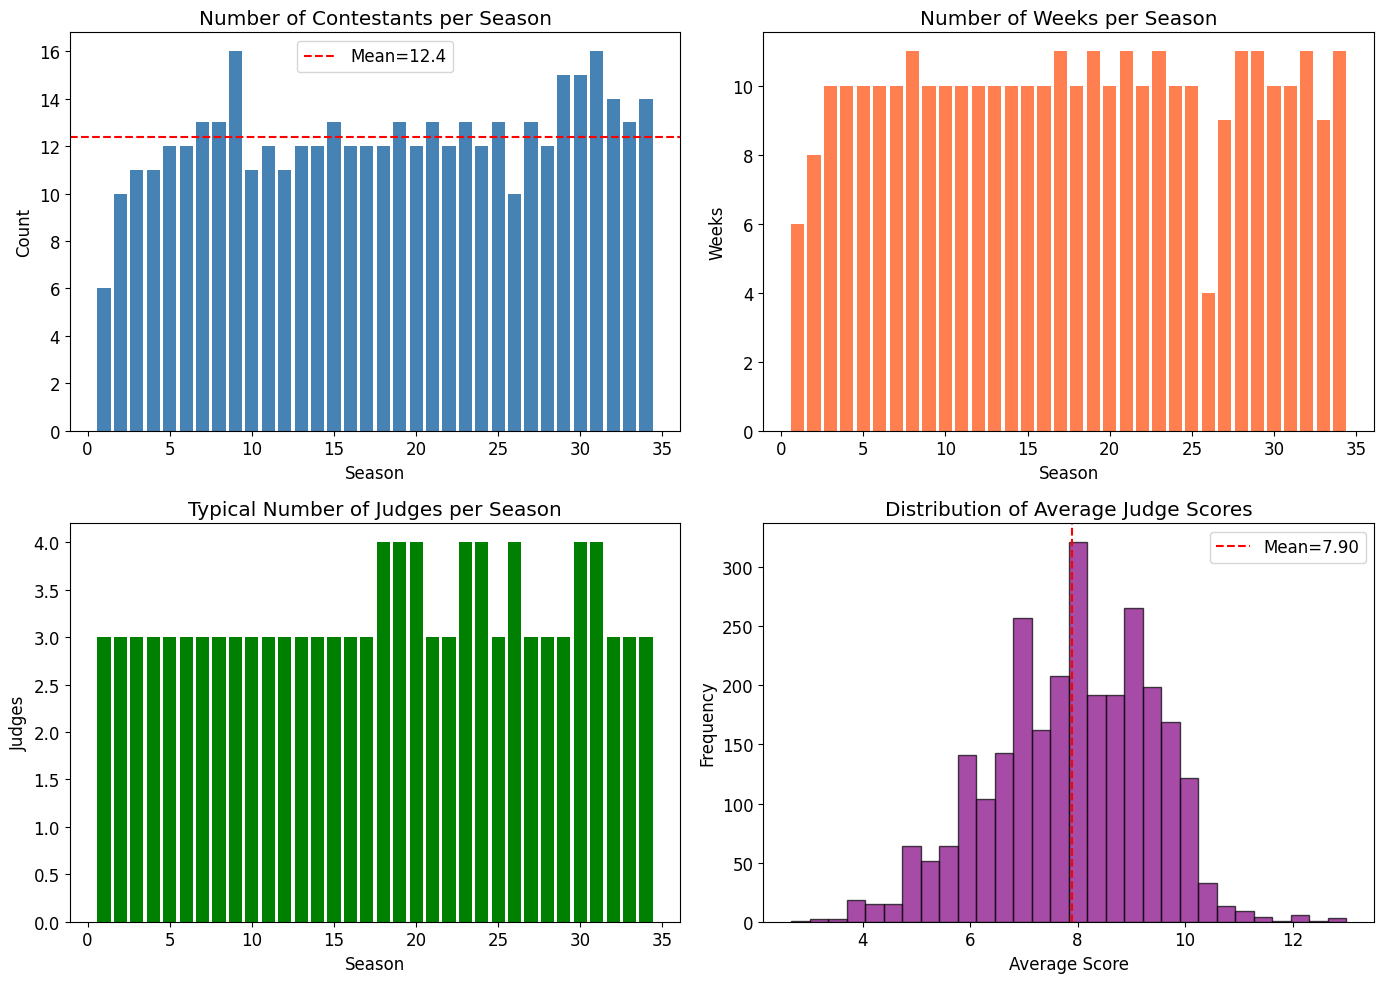

In [20]:
# 每季基本统计可视化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. 每季参赛人数
contestants_per_season = df_main.groupby('season').size()
axes[0,0].bar(contestants_per_season.index, contestants_per_season.values, color='steelblue')
axes[0,0].set_title('Number of Contestants per Season')
axes[0,0].set_xlabel('Season')
axes[0,0].set_ylabel('Count')
axes[0,0].axhline(y=contestants_per_season.mean(), color='red', linestyle='--', label=f'Mean={contestants_per_season.mean():.1f}')
axes[0,0].legend()

# 2. 每季周数
weeks_per_season = df_long.groupby('season')['week'].max()
axes[0,1].bar(weeks_per_season.index, weeks_per_season.values, color='coral')
axes[0,1].set_title('Number of Weeks per Season')
axes[0,1].set_xlabel('Season')
axes[0,1].set_ylabel('Weeks')

# 3. 每季评委数量分布
judges_per_season_week = df_long.groupby(['season'])['num_judges'].apply(lambda x: x.mode()[0] if len(x.mode()) > 0 else 3)
axes[1,0].bar(judges_per_season_week.index, judges_per_season_week.values, color='green')
axes[1,0].set_title('Typical Number of Judges per Season')
axes[1,0].set_xlabel('Season')
axes[1,0].set_ylabel('Judges')

# 4. 评委打分分布
axes[1,1].hist(df_long['avg_score'], bins=30, color='purple', alpha=0.7, edgecolor='black')
axes[1,1].set_title('Distribution of Average Judge Scores')
axes[1,1].set_xlabel('Average Score')
axes[1,1].set_ylabel('Frequency')
axes[1,1].axvline(x=df_long['avg_score'].mean(), color='red', linestyle='--', label=f"Mean={df_long['avg_score'].mean():.2f}")
axes[1,1].legend()

plt.tight_layout()
plt.savefig('fig2_season_statistics.png', dpi=150, bbox_inches='tight')
plt.show()

## 第五步：合并额外数据

In [21]:
# 合并专业舞者数据
print("合并专业舞者数据...")
df_season_summary = df_season_summary.merge(
    df_pro_dancer[['pro_dancer', 'wins', 'top3_finishes', 'avg_placement', 'avg_score', 'career_span']].rename(
        columns={
            'pro_dancer': 'ballroom_partner',
            'avg_placement': 'pro_avg_placement',
            'avg_score': 'pro_avg_score'
        }
    ),
    on='ballroom_partner',
    how='left'
)
print(f"✅ 合并后: {df_season_summary.shape}")

# 检查未匹配的舞者
unmatched = df_season_summary[df_season_summary['wins'].isna()]['ballroom_partner'].unique()
print(f"\n未匹配的专业舞者数量: {len(unmatched)}")
if len(unmatched) > 0:
    print(f"示例: {list(unmatched[:5])}")

合并专业舞者数据...
✅ 合并后: (421, 22)

未匹配的专业舞者数量: 0


In [22]:
# 合并维基百科页面浏览量数据（仅S21-S34可用）
print("\n合并页面浏览量数据...")
df_season_summary = df_season_summary.merge(
    df_pageviews[['celebrity_name', 'season', 'total_pageviews', 'avg_daily_pageviews']],
    on=['celebrity_name', 'season'],
    how='left'
)
print(f"✅ 合并后: {df_season_summary.shape}")

# 统计覆盖率
pageview_coverage = df_season_summary['total_pageviews'].notna().mean() * 100
print(f"页面浏览量数据覆盖率: {pageview_coverage:.1f}% (仅S21-S34)")


合并页面浏览量数据...
✅ 合并后: (421, 24)
页面浏览量数据覆盖率: 43.5% (仅S21-S34)


In [23]:
# 合并季节元数据
print("\n合并季节元数据...")
df_season_summary = df_season_summary.merge(
    df_season_meta[['season', 'num_weeks', 'year']],
    on='season',
    how='left'
)
print(f"✅ 最终数据: {df_season_summary.shape}")


合并季节元数据...
✅ 最终数据: (421, 26)


## 第六步：特征工程 - 建模所需变量

In [24]:
# 创建问题一所需特征：估算粉丝投票
print("创建问题一所需特征...")

# 在长格式数据中添加更多特征
# 1. 评委得分排名在当周的相对位置
df_long['judge_rank_pct'] = df_long['judge_rank'] / df_long['contestants_this_week']

# 2. 与当周平均分的差异
df_long['score_vs_week_avg'] = df_long['total_score'] - df_long.groupby(['season', 'week'])['total_score'].transform('mean')

# 3. 与当周最高分的差距
df_long['score_vs_week_max'] = df_long.groupby(['season', 'week'])['total_score'].transform('max') - df_long['total_score']

# 4. 选手的累积历史得分（不含当周，避免数据泄露）
df_long = df_long.sort_values(['season', 'celebrity_name', 'week'])
df_long['cumulative_avg_score'] = df_long.groupby(['season', 'celebrity_name'])['total_score'].transform(
    lambda x: x.shift(1).expanding().mean()
)

print("✅ 问题一特征创建完成")

创建问题一所需特征...
✅ 问题一特征创建完成


In [25]:
# 创建问题二所需特征：投票方式比较
print("\n创建问题二所需特征...")

# 标记投票方式（基于规则变更）
# 第1-2季：排名法
# 第3-27季：百分比法  
# 第28-34季：排名法
def get_voting_method(season):
    if season <= 2:
        return 'rank'
    elif season <= 27:
        return 'percentage'
    else:
        return 'rank'

df_long['actual_voting_method'] = df_long['season'].apply(get_voting_method)

# 标记是否有争议选手（评委低分但晋级深）
# 这些争议案例在题目中已列出
controversial_cases = [
    ('Jerry Rice', 2),
    ('Billy Ray Cyrus', 4),
    ('Bristol Palin', 11),
    ('Bobby Bones', 27)
]
df_long['is_controversial'] = df_long.apply(
    lambda x: (x['celebrity_name'], x['season']) in controversial_cases, axis=1
)

print("✅ 问题二特征创建完成")


创建问题二所需特征...
✅ 问题二特征创建完成


In [26]:
# 创建问题三所需特征：因素影响分析
print("\n创建问题三所需特征...")

# 1. 行业分类编码
industry_counts = df_season_summary['celebrity_industry'].value_counts()
print(f"行业分布:")
print(industry_counts)

# 2. 年龄分组
df_season_summary['age_group'] = pd.cut(
    df_season_summary['celebrity_age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '25-35', '35-45', '45-55', '55+']
)

# 3. 是否美国本土
df_season_summary['is_us'] = df_season_summary['celebrity_homestate'] != 'Non-US'

# 4. 专业舞者经验等级
df_season_summary['pro_experience_level'] = pd.cut(
    df_season_summary['career_span'].fillna(1),
    bins=[0, 3, 10, 35],
    labels=['New', 'Experienced', 'Veteran']
)

print("\n✅ 问题三特征创建完成")


创建问题三所需特征...
行业分布:
celebrity_industry
Actor/Actress               128
Athlete                      95
TV Personality               67
Singer/Rapper                61
Model                        17
Comedian                     12
Social Media Personality      8
Entrepreneur                  4
Racing Driver                 4
Radio Personality             4
Politician                    3
News Anchor                   3
Sports Broadcaster            2
Magician                      1
Beauty Pagent                 1
Astronaut                     1
Fashion Designer              1
Motivational Speaker          1
Military                      1
Journalist                    1
Musician                      1
Producer                      1
Fitness Instructor            1
Con artist                    1
Social media personality      1
Conservationist               1
Name: count, dtype: int64

✅ 问题三特征创建完成


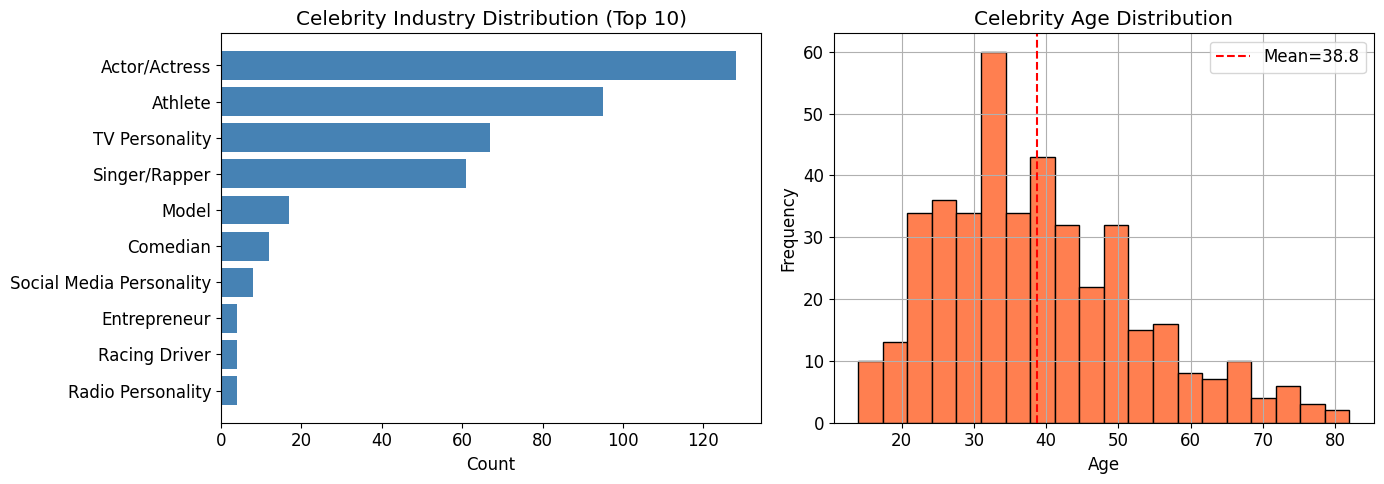

In [27]:
# 可视化：行业分布与名次
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 行业分布
industry_plot = industry_counts.head(10)
axes[0].barh(industry_plot.index[::-1], industry_plot.values[::-1], color='steelblue')
axes[0].set_title('Celebrity Industry Distribution (Top 10)')
axes[0].set_xlabel('Count')

# 年龄分布
df_season_summary['celebrity_age'].hist(ax=axes[1], bins=20, color='coral', edgecolor='black')
axes[1].set_title('Celebrity Age Distribution')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].axvline(x=df_season_summary['celebrity_age'].mean(), color='red', linestyle='--', 
               label=f"Mean={df_season_summary['celebrity_age'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('fig3_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

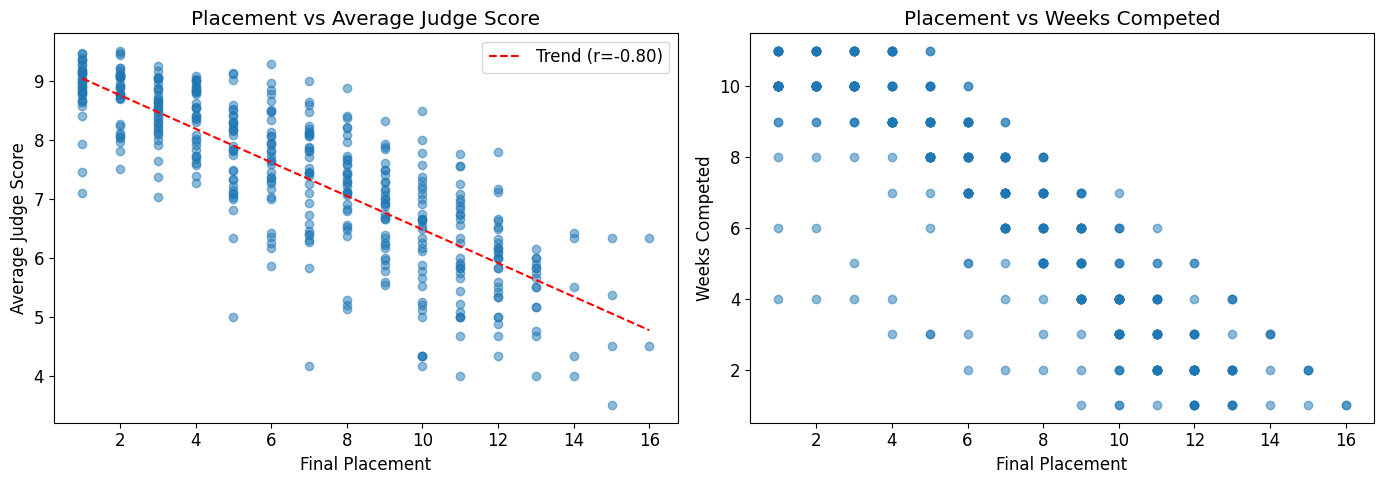

In [28]:
# 名次与得分的关系
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 名次 vs 平均得分
axes[0].scatter(df_season_summary['placement'], df_season_summary['avg_judge_score'], alpha=0.5)
axes[0].set_xlabel('Final Placement')
axes[0].set_ylabel('Average Judge Score')
axes[0].set_title('Placement vs Average Judge Score')

# 添加趋势线
z = np.polyfit(df_season_summary['placement'], df_season_summary['avg_judge_score'], 1)
p = np.poly1d(z)
axes[0].plot(range(1, 17), p(range(1, 17)), 'r--', label=f'Trend (r={np.corrcoef(df_season_summary["placement"], df_season_summary["avg_judge_score"])[0,1]:.2f})')
axes[0].legend()

# 名次 vs 参赛周数
axes[1].scatter(df_season_summary['placement'], df_season_summary['weeks_competed'], alpha=0.5)
axes[1].set_xlabel('Final Placement')
axes[1].set_ylabel('Weeks Competed')
axes[1].set_title('Placement vs Weeks Competed')

plt.tight_layout()
plt.savefig('fig4_placement_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 第七步：数据验证与导出

In [29]:
# 最终数据验证
print("="*60)
print("📋 最终数据验证")
print("="*60)

# 长格式数据
print(f"\n1. 长格式数据 (df_long): {df_long.shape}")
print(f"   - 季数覆盖: {df_long['season'].min()} - {df_long['season'].max()}")
print(f"   - 选手-周次记录: {len(df_long)}")
print(f"   - 缺失值: {df_long.isnull().sum().sum()}")

# 季汇总数据
print(f"\n2. 季汇总数据 (df_season_summary): {df_season_summary.shape}")
print(f"   - 选手总数: {len(df_season_summary)}")
print(f"   - 列: {list(df_season_summary.columns)}")

# 验证淘汰逻辑
print(f"\n3. 淘汰逻辑验证:")
eliminated_count = df_long[df_long['is_eliminated']].groupby('season').size()
print(f"   - 每季淘汰人数范围: {eliminated_count.min()} - {eliminated_count.max()}")

📋 最终数据验证

1. 长格式数据 (df_long): (2777, 28)
   - 季数覆盖: 1 - 34
   - 选手-周次记录: 2777
   - 缺失值: 421

2. 季汇总数据 (df_season_summary): (421, 29)
   - 选手总数: 421
   - 列: ['season', 'celebrity_name', 'ballroom_partner', 'celebrity_industry', 'celebrity_homestate', 'celebrity_homecountry/region', 'celebrity_age', 'placement', 'results', 'last_week', 'weeks_competed', 'total_score_sum', 'total_score_mean', 'total_score_std', 'avg_judge_score', 'avg_weekly_rank', 'season_contestants', 'wins', 'top3_finishes', 'pro_avg_placement', 'pro_avg_score', 'career_span', 'total_pageviews', 'avg_daily_pageviews', 'num_weeks', 'year', 'age_group', 'is_us', 'pro_experience_level']

3. 淘汰逻辑验证:
   - 每季淘汰人数范围: 3 - 13


In [30]:
# 构建淘汰数据（每周谁被淘汰）
def build_elimination_data(df_long):
    """构建每周淘汰数据"""
    eliminations = df_long[df_long['is_eliminated']][[
        'season', 'week', 'celebrity_name', 'ballroom_partner',
        'total_score', 'judge_rank', 'judge_score_pct', 'placement'
    ]].copy()
    
    eliminations = eliminations.rename(columns={'week': 'elimination_week'})
    return eliminations

df_eliminations = build_elimination_data(df_long)
print(f"\n淘汰数据: {df_eliminations.shape[0]} 条淘汰记录")
df_eliminations.head(10)


淘汰数据: 319 条淘汰记录


,season,elimination_week,celebrity_name,ballroom_partner,total_score,judge_rank,judge_score_pct,placement
14,1,3,Evander Holyfield,Edyta Sliwinska,13.00,5.00,12.26,5
18,1,4,Rachel Hunter,Jonathan Roberts,25.00,2.00,27.17,4
25,1,2,Trista Sutter,Louis van Amstel,19.00,4.00,15.70,6
38,2,6,George Hamilton,Edyta Sliwinska,23.00,4.00,17.29,5
64,2,3,Giselle Fernandez,Jonathan Roberts,22.00,5.00,12.09,8
77,2,1,Kenny Mayne,Andrea Hale,13.00,9.00,6.67,10
45,2,7,Lisa Rinna,Louis van Amstel,26.50,3.00,25.98,4
68,2,4,Master P,Ashly DelGrosso,8.00,7.00,5.06,7
27,2,2,Tatum O'Neal,Nick Kosovich,17.00,8.00,8.50,9
32,2,5,Tia Carrere,Maksim Chmerkoskiy,22.00,6.00,14.57,6


In [31]:
# 保存处理后的数据
print("\n保存数据...")

# 保存长格式数据（用于问题一、二）
df_long.to_csv('data_long_format.csv', index=False)
print(f"✅ 保存: data_long_format.csv ({df_long.shape})")

# 保存季汇总数据（用于问题三）
df_season_summary.to_csv('data_season_summary.csv', index=False)
print(f"✅ 保存: data_season_summary.csv ({df_season_summary.shape})")

# 保存淘汰数据（用于问题一、二验证）
df_eliminations.to_csv('data_eliminations.csv', index=False)
print(f"✅ 保存: data_eliminations.csv ({df_eliminations.shape})")


保存数据...
✅ 保存: data_long_format.csv ((2777, 28))
✅ 保存: data_season_summary.csv ((421, 29))
✅ 保存: data_eliminations.csv ((319, 8))


## 预处理总结

### 处理决策记录

| 处理项 | 决策 | 理由 |
|-------|------|------|
| N/A值（Judge4） | 保留 | 大多数季只有3个评委，N/A表示无此评委 |
| N/A值（后期周次） | 保留 | 季节结束或选手淘汰，非真正缺失 |
| 0分 | 排除计算 | 表示选手已被淘汰，非真实表演得分 |
| homestate缺失 | 填充'Non-US' | 仅非美国选手缺失，业务合理 |
| 舞者数据未匹配 | 填充NA | 部分替补舞者数据不全 |
| 页面浏览量 | 仅S21-S34可用 | 爬虫数据覆盖范围限制 |

### 输出文件

1. **data_long_format.csv**: 长格式数据（每行=选手×周），包含周内排名、得分百分比等，用于问题一二
2. **data_season_summary.csv**: 季汇总数据（每行=选手×季），包含舞者经验、人口统计特征等，用于问题三
3. **data_eliminations.csv**: 淘汰记录，用于验证投票估算

### 后续建模建议

- **问题一**: 使用`data_long_format.csv`，基于淘汰约束进行贝叶斯推断
- **问题二**: 使用长格式数据，模拟两种投票方式的结果差异
- **问题三**: 使用`data_season_summary.csv`，建立混合效应模型
- **问题四**: 综合使用所有数据设计新投票系统

In [32]:
# 输出关键统计量（供论文引用）
print("="*60)
print("📊 关键统计量（可用于论文引用）")
print("="*60)

stats = {
    '总季数': 34,
    '总选手数': len(df_season_summary),
    '总选手-周次记录': len(df_long),
    '平均评委得分': f"{df_long['avg_score'].mean():.2f} (std={df_long['avg_score'].std():.2f})",
    '平均每季选手数': f"{df_season_summary.groupby('season').size().mean():.1f}",
    '平均每季周数': f"{df_long.groupby('season')['week'].max().mean():.1f}",
    '选手平均年龄': f"{df_season_summary['celebrity_age'].mean():.1f} (range: {df_season_summary['celebrity_age'].min()}-{df_season_summary['celebrity_age'].max()})",
    '行业类别数': df_season_summary['celebrity_industry'].nunique(),
    '专业舞者数': df_season_summary['ballroom_partner'].nunique(),
}

for k, v in stats.items():
    print(f"{k}: {v}")

📊 关键统计量（可用于论文引用）
总季数: 34
总选手数: 421
总选手-周次记录: 2777
平均评委得分: 7.90 (std=1.46)
平均每季选手数: 12.4
平均每季周数: 9.9
选手平均年龄: 38.8 (range: 14-82)
行业类别数: 26
专业舞者数: 60
